# OrbitTails Tutorial

Learn how to set up a potential in gala, simulate an orbit, calculate 3D tail angles, project into a two-dimensional viewing frame, and compare 2D and 3D tail angles.

In [4]:
from gala import potential as gp
from gala import dynamics as gd
from gala import integrate as gi
from gala.units import galactic

from astropy import units as u

import numpy as np

from matplotlib import pyplot as plt

import matplotlib.animation as animation

import plotting_utils as pu
from transforms import *

from orbit import Orbit
from orbit import Projected_Orbit

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Set up host potential and initial conditions

We'll simulate a (rough) Coma cluster analogue. However, there are many choices for gravitational potential. You can use any potential defined in the `gala.potential` library.

The Navarro-Frenk-White profile is a mathematical model that descries the density distribution of dark matter halos. It is commonly used to understand the structure of galaxies and their formation. We can use this potential with a Virial Mass of $1.26\times10^{15} M_{\odot}$ and concentration 4 to approximate a Coma cluster potential.

In [5]:
# initialize the potential model, ensuring that you use units for all models.
host_potential = gp.NFWPotential.from_M200_c(1.26e15 * u.Msun, 4, units=galactic)

In [6]:
# these are the units of the galactic units system defined in gala
host_potential.units

<UnitSystem (kpc, Myr, solMass, rad)>

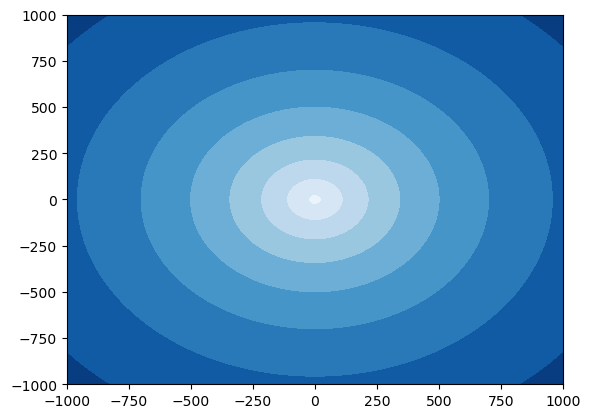

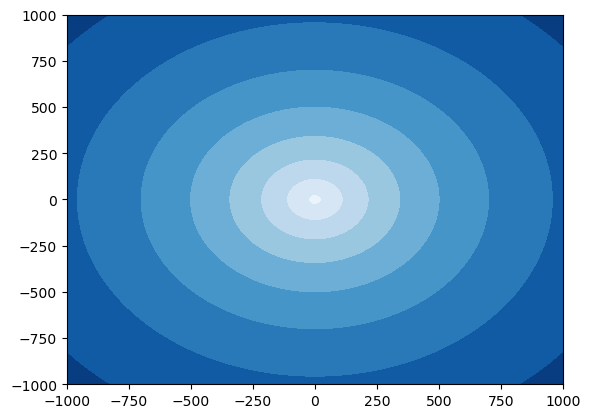

In [7]:
# try plotting potential contours
x = np.linspace(-1000, 1000, 100)
z = np.linspace(-1000, 1000, 100)
host_potential.plot_contours(grid=(x, 1., z))

In [8]:
# use gd.PhaseSpacePosition to define initial conditions and other positions in phase space, using cartesian position and velocity vectors
# pass them in with units when the potential also has unit system--you can use any length and velocity units
initial_conditions = gd.PhaseSpacePosition(pos=[400,0,0.] * u.kpc,
                                           vel=[50,1200, 100] * u.km/u.s)

# use the code below to set up initial conditions in cylindrical coordinates
# from astropy.coordinates import CylindricalRepresentation, CylindricalDifferential
# rho = 400 * u.kpc
# phi = 0*u.deg
# z = 0*u.kpc
# d_rho = 50*u.km/u.s
# d_z = 100*u.km/u.s
# v_phi_tangential = 1200*u.km/u.s
# angular_velocity = v_phi_tangential / rho * u.rad # → rad/s
# pos = CylindricalRepresentation(rho=rho, phi=phi, z=z)
# vel = CylindricalDifferential(d_rho=d_rho, d_phi=angular_velocity.to(u.rad/u.s), d_z=d_z)
# initial_conditions = gd.PhaseSpacePosition(pos.with_differentials(vel))

## Simulate an Orbit and Calculate Tail Angles

In [9]:
orbit = Orbit(host_potential, initial_conditions, n_steps=2000)

In [11]:
# calculate the galaxy's 3d tail angles
orbit.calc_3d_tail_angles()

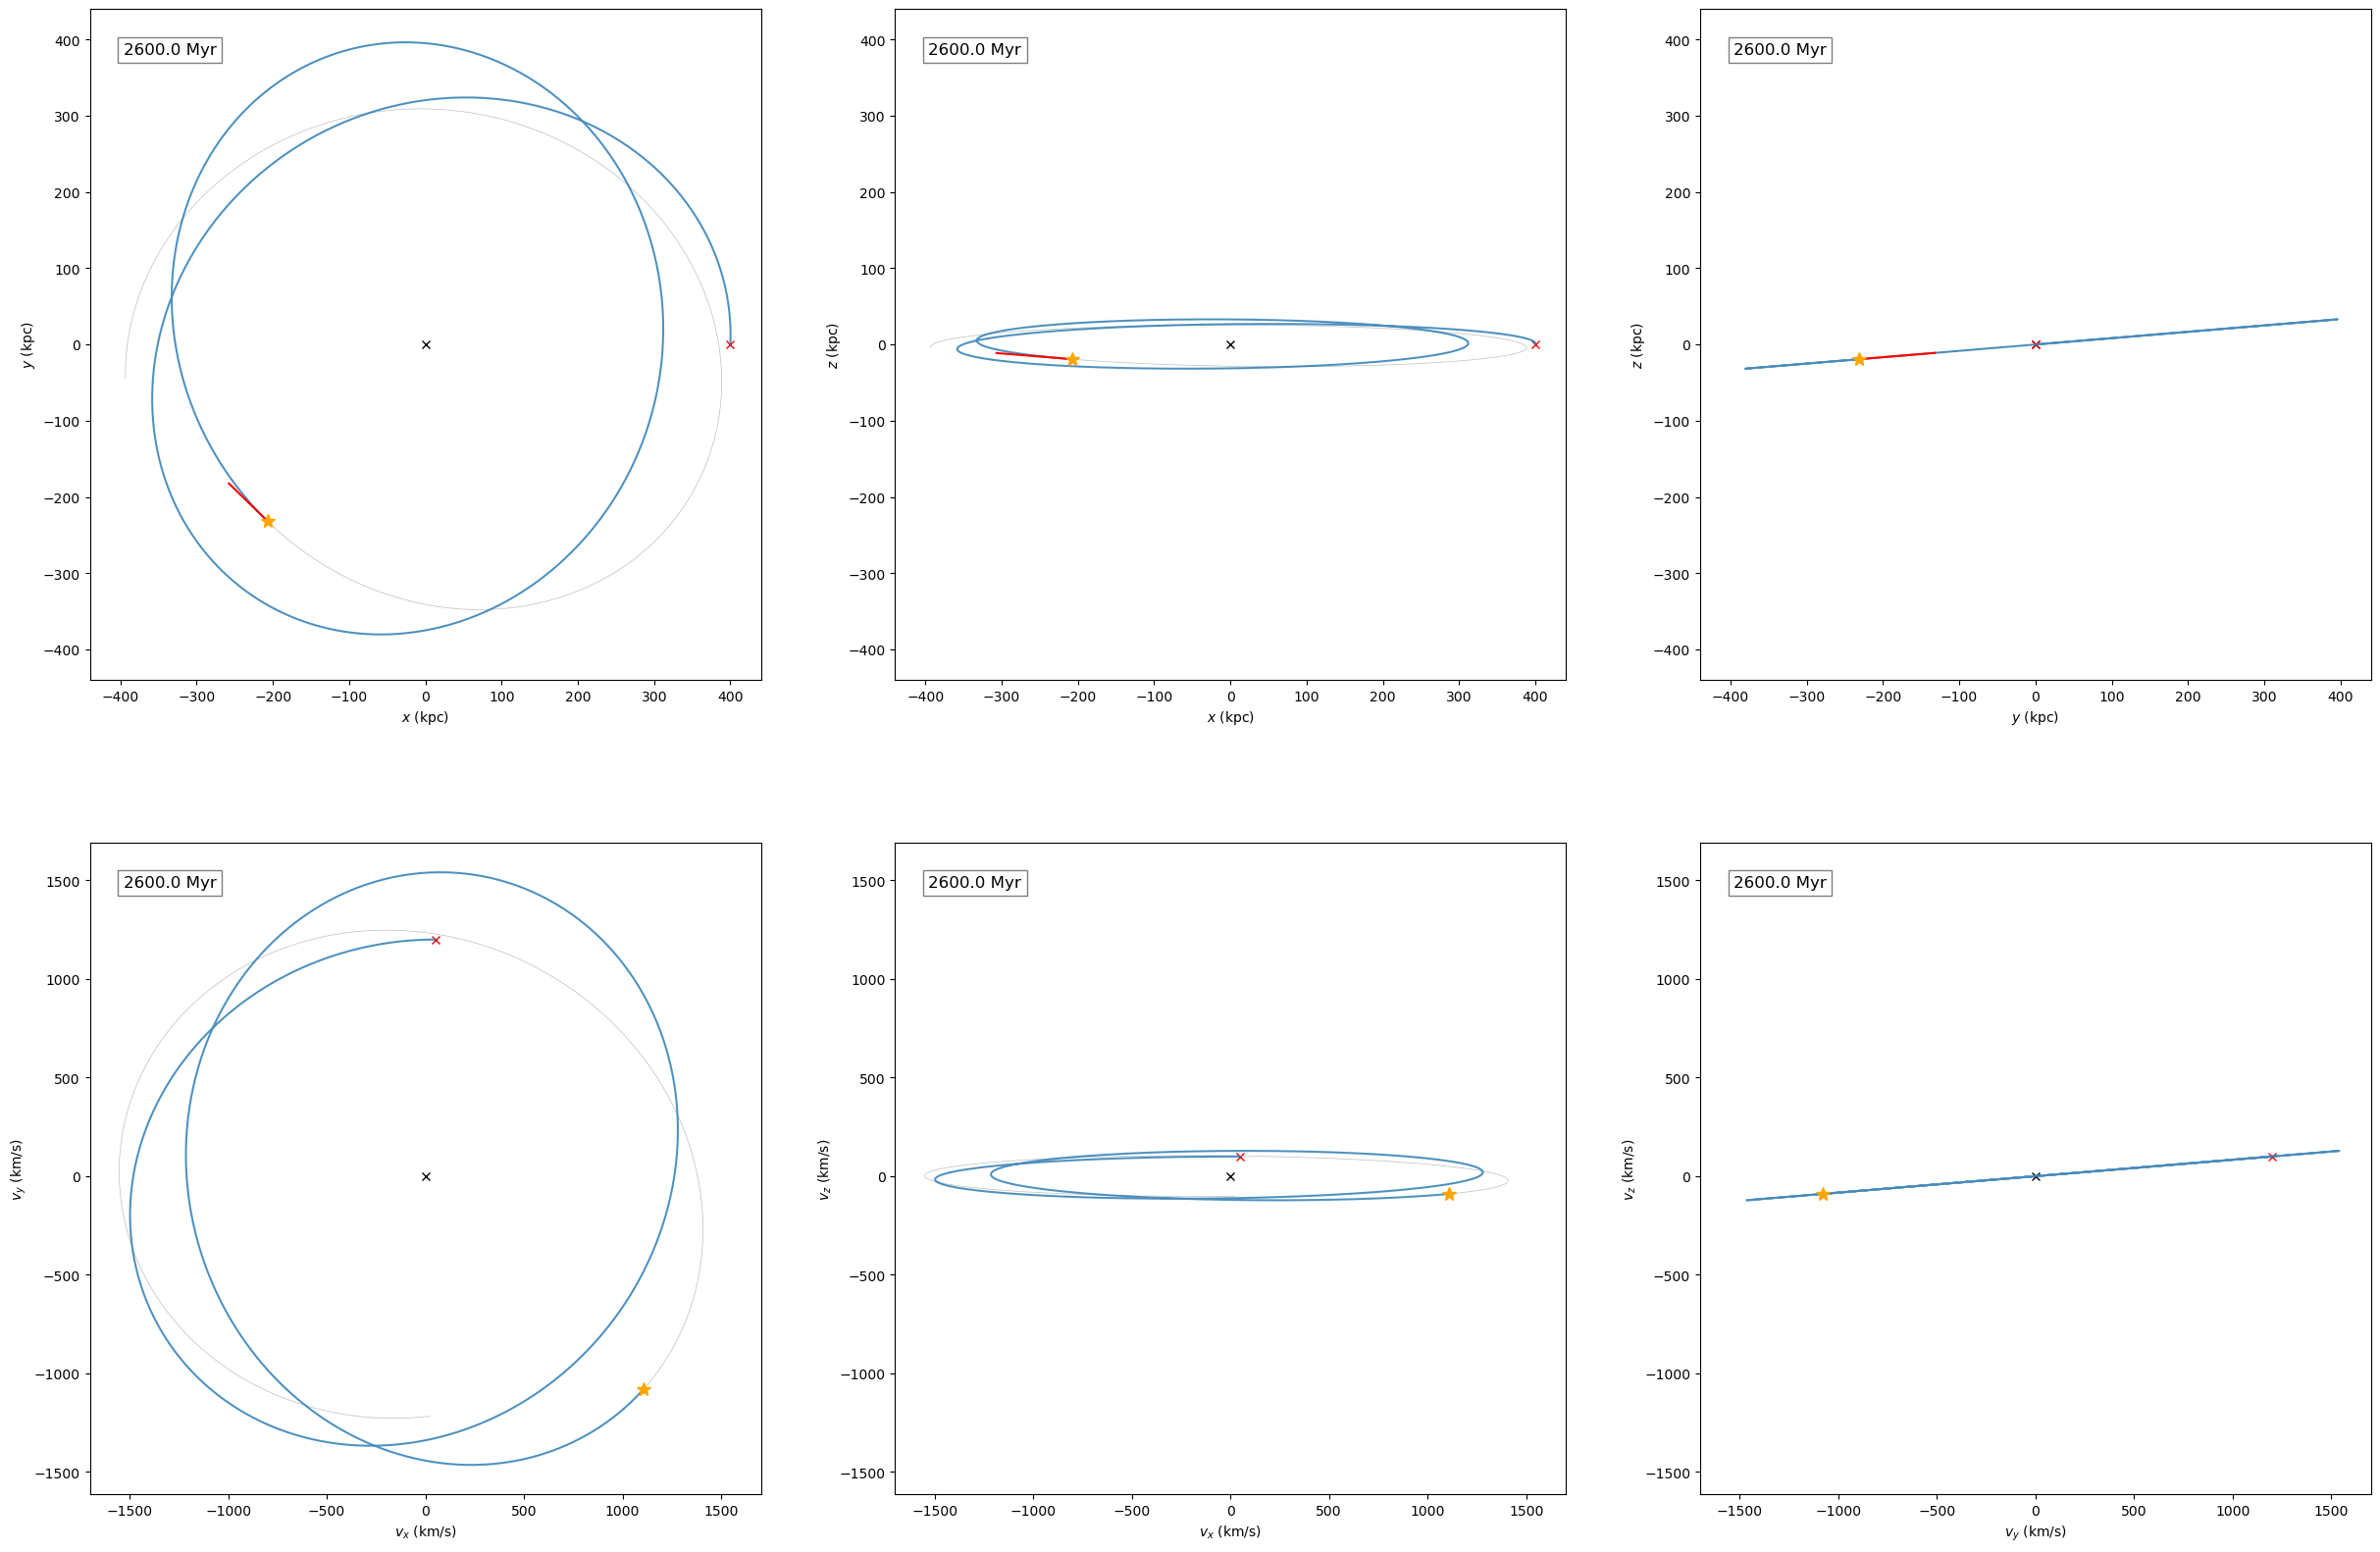

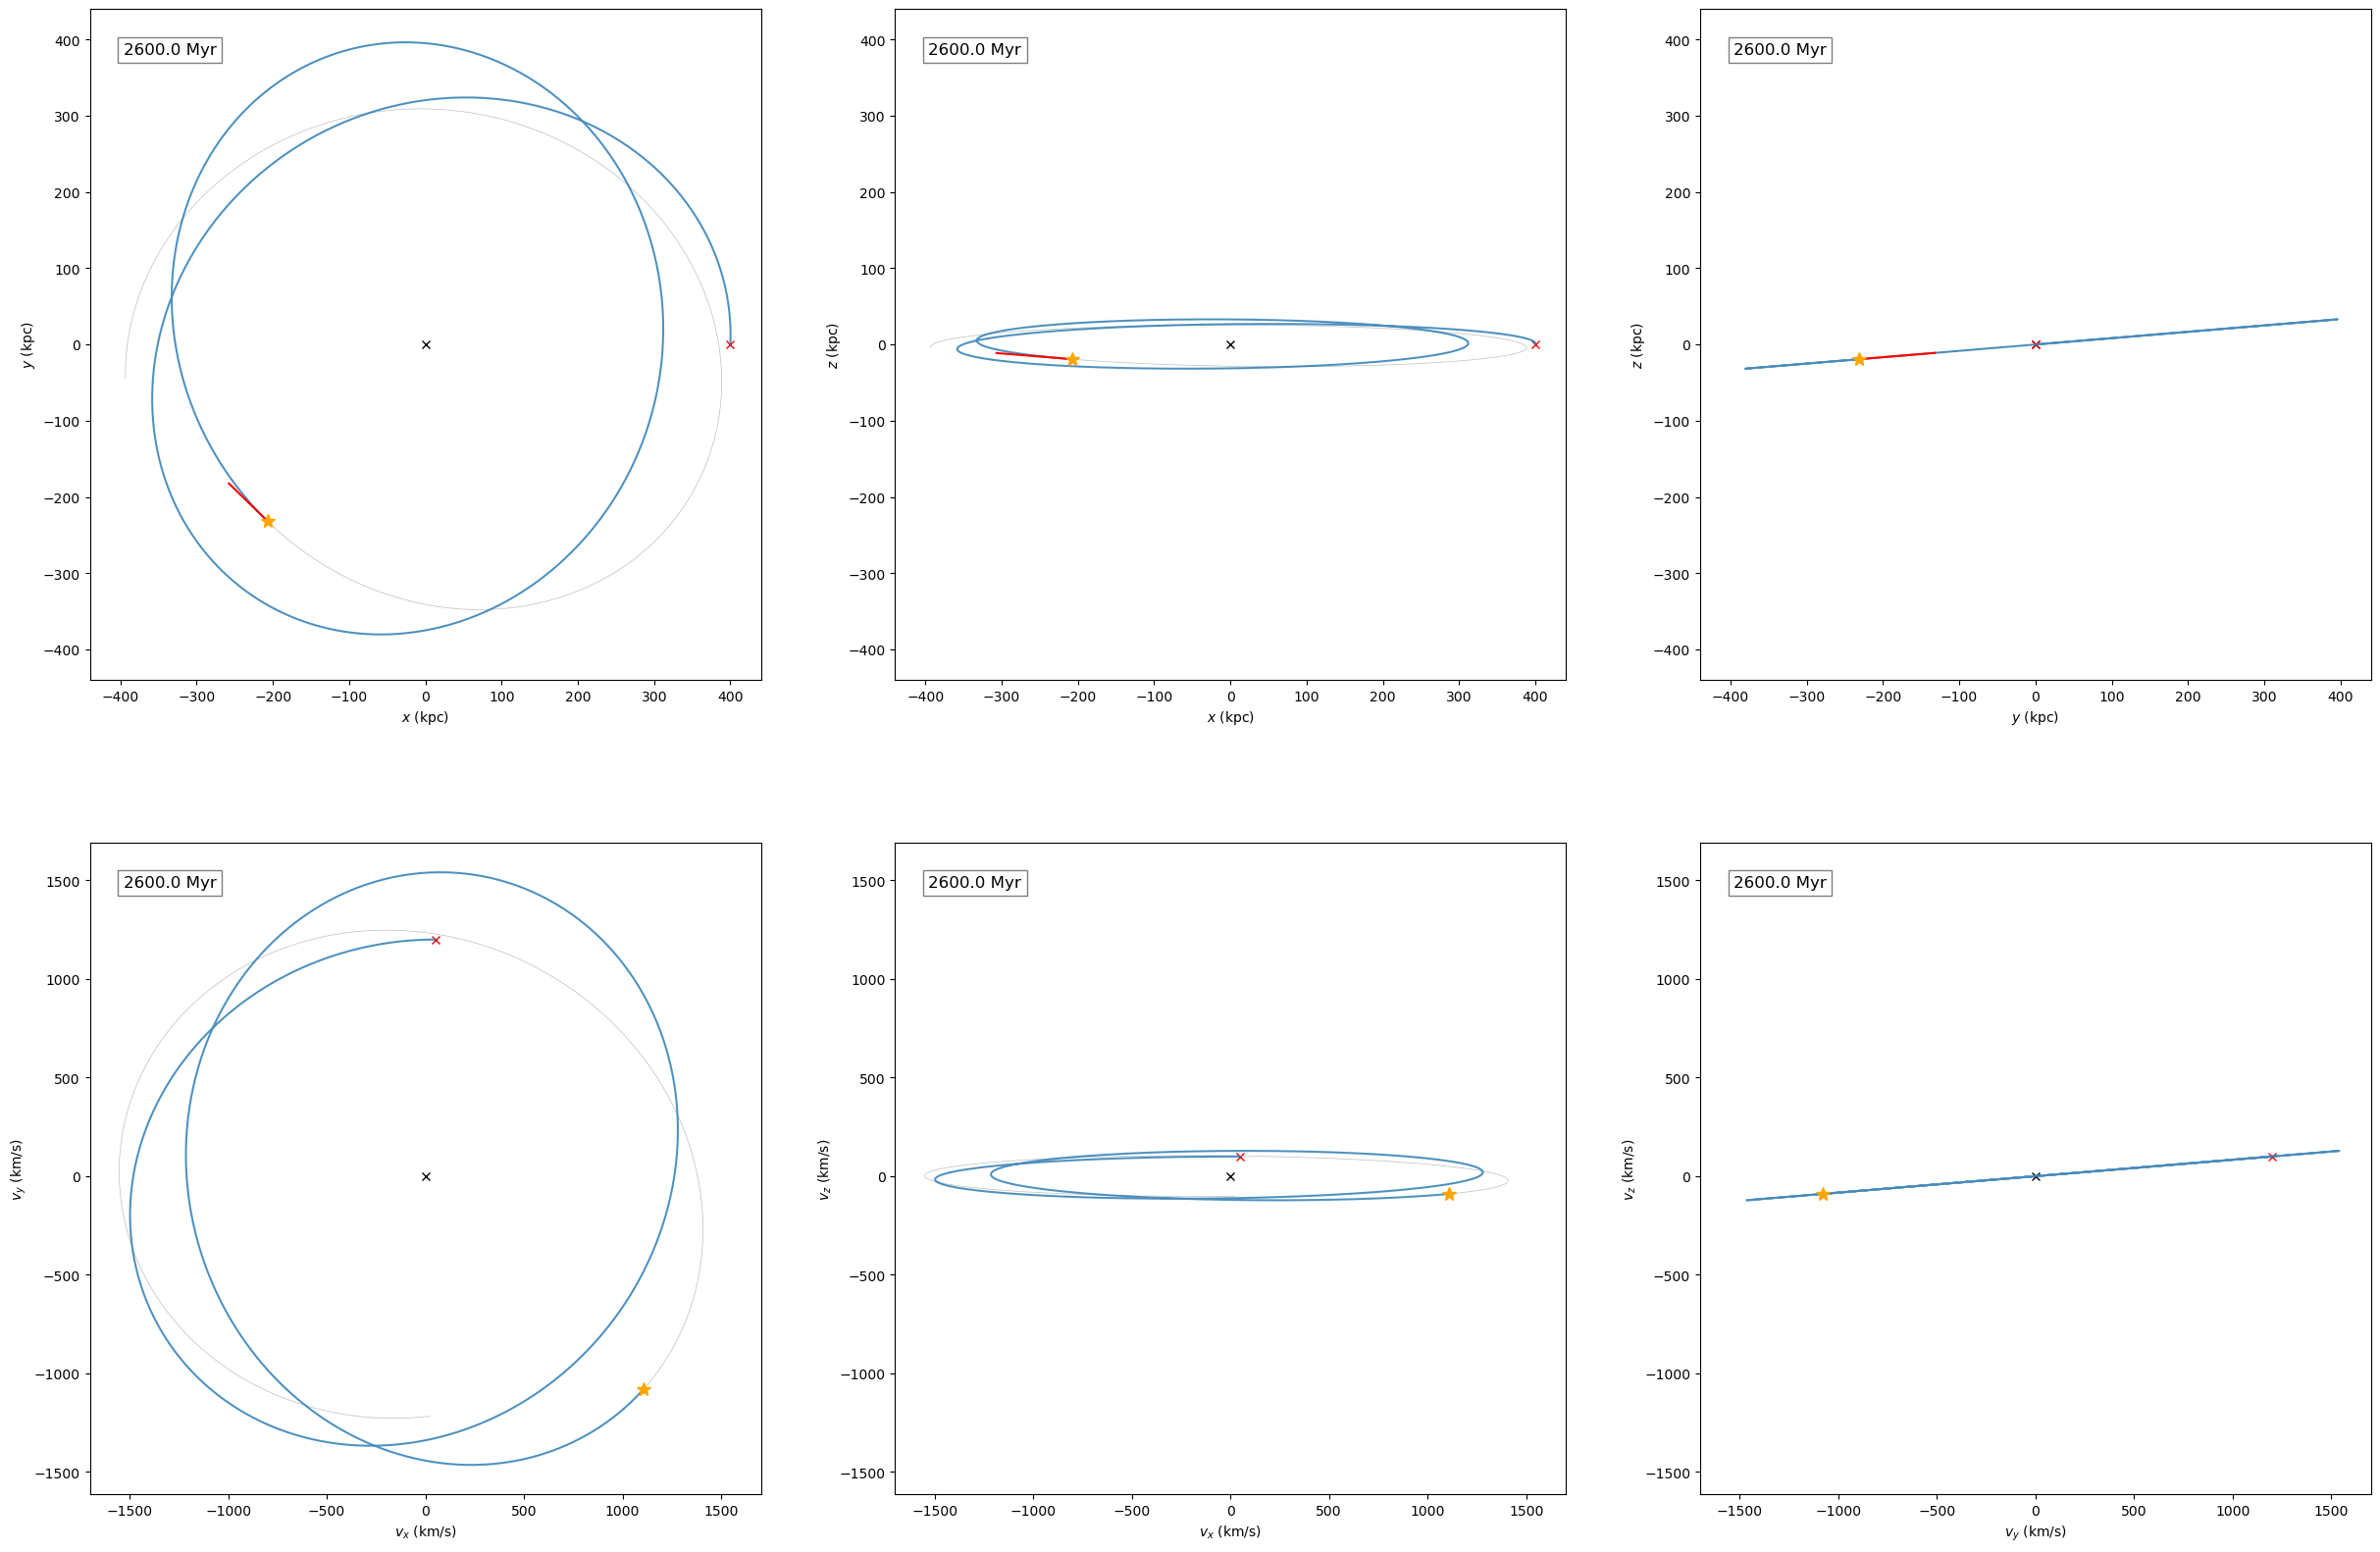

In [12]:
# plot the orbit in main Cartesian projection
# use time_index to indicate at what time you want to see the tails!
orbit.plot_orbits_not_animated(time_index=1300, with_tails=True)

In [312]:
# check out the 3D tail angle for the same time index
orbit.tail_3d_radial_angle_deg[1500]

85.31942152051934

## Projecting the Orbit Based on the Viewing Angle

In [15]:
# generate the projected 2D orbit and tail angles
# input a viewing direction vector corresponding to the direction the viewer is looking
tail_vectors_2d = orbit.project_orbit_tail_angles(view_dir = [1, 0, 0])

In [16]:
# check out the 2D tail angle at your favorite time in the orbit! 2D tail angles are measured relative to the direction to cluster center
print(tail_vectors_2d.tail_angles_2d_relative_deg[1500])

179.99999999999997


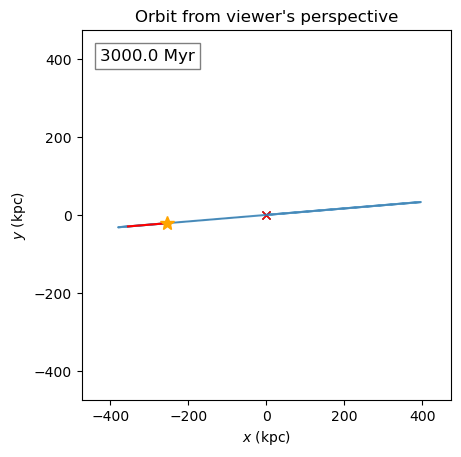

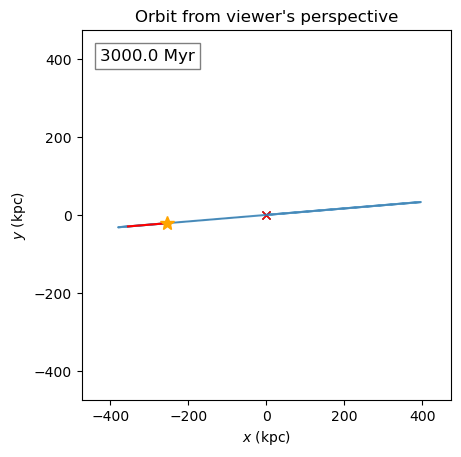

In [20]:
# plot your projected orbit
tail_vectors_2d.plot_projected_orbit(1500, with_tail=True)

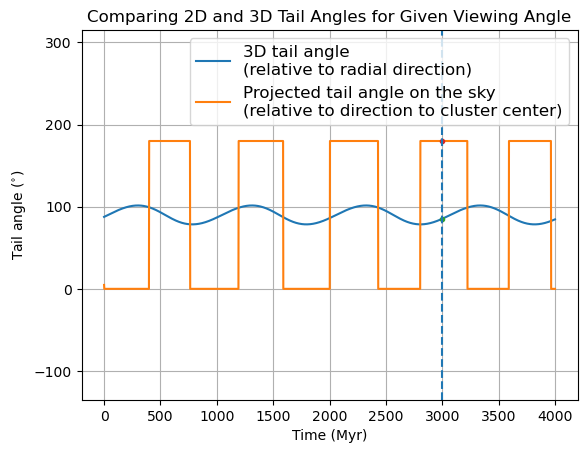

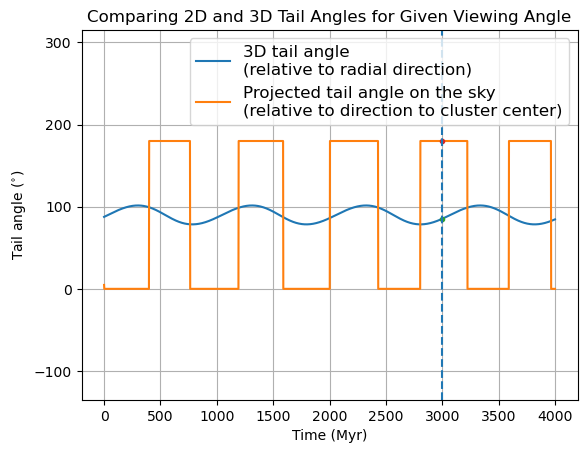

In [21]:
# compare the 2D and 3D tail angles
tail_vectors_2d.comparison_plots(1500)